# Formative Assignment: Advanced Linear Algebra (PCA)

This notebook implements **Principal Component Analysis (PCA) from scratch** on an Africanized dataset.

**Dataset:** African socio-economic indicators (30 countries, 10 columns). Themes: *economic activity* (GDP per capita, agriculture share of GDP) and *population pressure* (population density, urbanisation).

It satisfies the brief: **7+ columns**, **missing/NaN values**, and **at least one non-numeric column** (`Country`).

> **Library note:** All PCA mathematics (standardisation, covariance, eigendecomposition, sorting, projection) uses **numpy only** — no `sklearn`. `pandas` is used solely to *load and clean* the raw CSV (separate the non-numeric column, impute NaN) and `matplotlib` solely to *visualise*, since neither can be done in numpy.

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd            # loading & cleaning only
import matplotlib.pyplot as plt  # visualisation only

np.random.seed(42)

# Load the raw Africanized dataset
df = pd.read_csv('african_socioeconomic.csv')
print('Raw shape:', df.shape)
print('Missing values per column:')
print(df.isna().sum())
df.head()

Raw shape: (30, 10)
Missing values per column:
Country                   0
GDP_per_capita_USD        1
Pop_density_km2           1
Agric_pct_GDP             0
Mobile_per_100            2
Internet_users_pct        1
Urban_pop_pct             0
Life_expectancy           2
Electricity_access_pct    2
Literacy_rate_pct         2
dtype: int64


,Country,GDP_per_capita_USD,Pop_density_km2,Agric_pct_GDP,Mobile_per_100,Internet_users_pct,Urban_pop_pct,Life_expectancy,Electricity_access_pct,Literacy_rate_pct
0,Nigeria,2160.0,226.0,23.4,91.0,55.0,53,53.0,60.0,62.0
1,Egypt,3690.0,103.0,11.3,95.0,72.0,43,70.0,100.0,71.0
2,South Africa,6770.0,49.0,2.5,168.0,72.0,68,NaN,85.0,95.0
3,Kenya,2080.0,94.0,21.2,122.0,42.0,28,62.0,71.0,82.0
4,Ethiopia,925.0,115.0,37.6,56.0,17.0,22,65.0,51.0,52.0


### Step 0: Inspect, separate the non-numeric column, and handle missing values

The brief requires a non-numeric column and NaN values. PCA operates only on numeric features, so we:
1. keep `Country` aside as **labels** (used later for plotting),
2. impute missing numeric values with the **column mean** (a simple, leakage-free choice for this small dataset).

In [2]:
# Separate the non-numeric label column
labels = df['Country'].values                      # non-numeric column kept as labels
features_df = df.drop(columns=['Country'])         # numeric feature matrix
feature_names = features_df.columns.tolist()

# Impute NaN with column means, then convert to a pure numpy array
data = features_df.values.astype(float)            # may contain NaN
col_means = np.nanmean(data, axis=0)               # mean ignoring NaN
nan_mask = np.isnan(data)
data[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

print('Clean numeric matrix shape:', data.shape)
print('Remaining NaN:', int(np.isnan(data).sum()))
print('Features:', feature_names)
data[:5]

Clean numeric matrix shape: (30, 9)
Remaining NaN: 0
Features: ['GDP_per_capita_USD', 'Pop_density_km2', 'Agric_pct_GDP', 'Mobile_per_100', 'Internet_users_pct', 'Urban_pop_pct', 'Life_expectancy', 'Electricity_access_pct', 'Literacy_rate_pct']


array([[2.16e+03, 2.26e+02, 2.34e+01, 9.10e+01, 5.50e+01, 5.30e+01,
        5.30e+01, 6.00e+01, 6.20e+01],
       [3.69e+03, 1.03e+02, 1.13e+01, 9.50e+01, 7.20e+01, 4.30e+01,
        7.00e+01, 1.00e+02, 7.10e+01],
       [6.77e+03, 4.90e+01, 2.50e+00, 1.68e+02, 7.20e+01, 6.80e+01,
        6.45e+01, 8.50e+01, 9.50e+01],
       [2.08e+03, 9.40e+01, 2.12e+01, 1.22e+02, 4.20e+01, 2.80e+01,
        6.20e+01, 7.10e+01, 8.20e+01],
       [9.25e+02, 1.15e+02, 3.76e+01, 5.60e+01, 1.70e+01, 2.20e+01,
        6.50e+01, 5.10e+01, 5.20e+01]])

### Step 1: Load and Standardize the Data
Before applying PCA we standardize so every feature has mean 0 and standard deviation 1. This implements the z-score formula  $z = \dfrac{x - \mu}{\sigma}$  (per the assignment image), using numpy only.

In [ ]:
# Step 1: Standardize the data (numpy only) -> z = (x - mean) / std
mean = np.mean(data, axis=0)
std  = np.std(data, axis=0)            # population std (ddof=0)
standardized_data = (data - mean) / std

print('Means after standardization (~0):', np.round(standardized_data.mean(axis=0), 6))
print('Stds  after standardization (~1):', np.round(standardized_data.std(axis=0), 6))
standardized_data[:5]  # first few rows of standardized data

Means after standardization (~0): [-0. -0.  0. -0.  0.  0. -0.  0.  0.]
Stds  after standardization (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[-0.22291479,  0.82006032,  0.35450519, -0.23806452,  0.52271175,
         0.34710696, -2.1078162 ,  0.12165176, -0.4183409 ],
       [ 0.38728505, -0.07530398, -0.61890921, -0.12213745,  1.32301267,
        -0.19808722,  1.00808601,  1.78323677,  0.11409297],
       [ 1.61566119, -0.46839074, -1.32684696,  1.99353162,  1.32301267,
         1.16489822,  0.        ,  1.16014239,  1.53391662],
       [-0.25482066, -0.14081844,  0.17752075,  0.66037029, -0.08928306,
        -1.01587848, -0.45822091,  0.57858764,  0.76484548],
       [-0.71546171,  0.01204864,  1.49685928, -1.25242641, -1.26619617,
        -1.34299499,  0.09164418, -0.25220487, -1.00993409]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix shows how every pair of features varies together. It is the core object PCA decomposes.

In [ ]:
# Step 3: Covariance matrix (numpy only). rowvar=False -> columns are variables.
cov_matrix = np.cov(standardized_data, rowvar=False)
print('Covariance matrix shape:', cov_matrix.shape)
np.round(cov_matrix, 3)

Covariance matrix shape: (9, 9)


array([[ 1.034,  0.268, -0.68 ,  0.653,  0.739,  0.589,  0.539,  0.733,
         0.64 ],
       [ 0.268,  1.034, -0.013,  0.077,  0.003, -0.391,  0.184,  0.147,
         0.126],
       [-0.68 , -0.013,  1.034, -0.452, -0.636, -0.55 , -0.446, -0.584,
        -0.758],
       [ 0.653,  0.077, -0.452,  1.034,  0.696,  0.549,  0.288,  0.74 ,
         0.269],
       [ 0.739,  0.003, -0.636,  0.696,  1.034,  0.766,  0.639,  0.84 ,
         0.509],
       [ 0.589, -0.391, -0.55 ,  0.549,  0.766,  1.034,  0.314,  0.574,
         0.375],
       [ 0.539,  0.184, -0.446,  0.288,  0.639,  0.314,  1.034,  0.435,
         0.5  ],
       [ 0.733,  0.147, -0.584,  0.74 ,  0.84 ,  0.574,  0.435,  1.034,
         0.482],
       [ 0.64 ,  0.126, -0.758,  0.269,  0.509,  0.375,  0.5  ,  0.482,
         1.034]])

**Why compute a covariance matrix? (max 5 lines)**

The covariance matrix measures how every pair of features varies together, summarising the linear relationships and redundancy in the data in one symmetric matrix. PCA needs it for two reasons: (1) its **eigenvectors** give the orthogonal directions of maximum variance — the principal components; and (2) its **eigenvalues** quantify how much variance each direction carries, which lets us rank components and decide how many to keep.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix yields the eigenvalues and eigenvectors used by PCA. Because the covariance matrix is symmetric we use `np.linalg.eigh`, which returns real values and is numerically stable for symmetric matrices.

In [5]:
# Step 4: Eigendecomposition (numpy only)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print('Eigenvalues:\n', np.round(eigenvalues, 4))
print('\nEigenvectors (columns) shape:', eigenvectors.shape)
eigenvalues, eigenvectors

Eigenvalues:
 [0.0905 0.1771 0.2466 0.2907 0.3223 0.6766 0.9996 1.4123 5.0948]

Eigenvectors (columns) shape: (9, 9)


(array([0.09049486, 0.17706143, 0.24656649, 0.29066   , 0.32225823,
        0.67661156, 0.99963275, 1.41225282, 5.09480669]),
 array([[ 0.2095097 ,  0.60084683,  0.24944853, -0.22314115, -0.52928629,
         -0.13259014, -0.06293969,  0.15933423, -0.39496748],
        [-0.13324593, -0.34516835, -0.23789059,  0.12271081, -0.28539159,
         -0.09358738, -0.28952904,  0.78480548, -0.03874003],
        [ 0.03493852, -0.13793226,  0.70870831,  0.17352517, -0.20195048,
          0.37061804, -0.37577519, -0.01727191,  0.35739124],
        [-0.0509883 , -0.26137766,  0.1452171 , -0.60903282,  0.32484834,
         -0.14258003, -0.54077328, -0.09903775, -0.33011091],
        [ 0.7396366 , -0.25703455, -0.1575975 ,  0.30544106,  0.01814215,
          0.27041016, -0.12157607, -0.10927444, -0.41056948],
        [-0.43551683, -0.35174866, -0.09250997,  0.09741367, -0.56840364,
          0.04122549,  0.01414295, -0.48475028, -0.32952293],
        [-0.2579152 ,  0.0756585 , -0.01385706, -0.2377602

### Step 5: Sort Principal Components
`eigh` returns eigenvalues in *ascending* order, so we sort them **descending**: the larger the eigenvalue, the more variance (information) that component holds. We also compute the explained-variance ratio, used in Step 6 to choose the number of components.

In [ ]:
# Step 5: Sort eigenvalues (and matching eigenvectors) in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance ratio + cumulative
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print('Sorted eigenvalues:        ', np.round(sorted_eigenvalues, 4))
print('Explained variance ratio:  ', np.round(explained_variance_ratio, 4))
print('Cumulative variance:       ', np.round(cumulative_variance, 4))
sorted_eigenvectors

Sorted eigenvalues:         [5.0948 1.4123 0.9996 0.6766 0.3223 0.2907 0.2466 0.1771 0.0905]
Explained variance ratio:   [0.5472 0.1517 0.1074 0.0727 0.0346 0.0312 0.0265 0.019  0.0097]
Cumulative variance:        [0.5472 0.6989 0.8063 0.8789 0.9136 0.9448 0.9713 0.9903 1.    ]


array([[-0.39496748,  0.15933423, -0.06293969, -0.13259014, -0.52928629,
        -0.22314115,  0.24944853,  0.60084683,  0.2095097 ],
       [-0.03874003,  0.78480548, -0.28952904, -0.09358738, -0.28539159,
         0.12271081, -0.23789059, -0.34516835, -0.13324593],
       [ 0.35739124, -0.01727191, -0.37577519,  0.37061804, -0.20195048,
         0.17352517,  0.70870831, -0.13793226,  0.03493852],
       [-0.33011091, -0.09903775, -0.54077328, -0.14258003,  0.32484834,
        -0.60903282,  0.1452171 , -0.26137766, -0.0509883 ],
       [-0.41056948, -0.10927444, -0.12157607,  0.27041016,  0.01814215,
         0.30544106, -0.1575975 , -0.25703455,  0.7396366 ],
       [-0.32952293, -0.48475028,  0.01414295,  0.04122549, -0.56840364,
         0.09741367, -0.09250997, -0.35174866, -0.43551683],
       [-0.28682783,  0.24532393,  0.25020012,  0.80500226,  0.13398075,
        -0.2377602 , -0.01385706,  0.0756585 , -0.2579152 ],
       [-0.3838093 ,  0.00880204, -0.31183433, -0.06881369,  0

### Step 6: Project Data onto Principal Components
We **dynamically** select the smallest number of components whose **cumulative explained variance** reaches a threshold (90%), then project the standardized data onto those components.

In [7]:
# Step 6: Dynamically choose number of components, then project
variance_threshold = 0.90
num_components = int(np.argmax(cumulative_variance >= variance_threshold) + 1)
print(f'Components to retain >= {variance_threshold:.0%} variance: {num_components}')
print(f'Variance actually retained: {cumulative_variance[num_components-1]:.2%}')

# Projection: standardized data onto the top-k eigenvectors
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
print('Projected (reduced) data shape:', reduced_data.shape)
reduced_data[:5]

Components to retain >= 90% variance: 5
Variance actually retained: 91.36%
Projected (reduced) data shape: (30, 5)


array([[ 0.62213135, -0.20100286, -1.08238895, -1.30699944, -0.74716511],
       [-1.8183163 ,  0.26306464, -0.10857256,  0.74820278,  0.83828161],
       [-3.60739674, -0.6716177 , -0.20628109, -1.07646921,  0.18479911],
       [-0.00840745,  0.33092463, -0.24406101, -0.6834956 ,  1.18174769],
       [ 2.58131682,  0.59779086, -0.16374832,  0.82069742,  0.19107812]])

### Step 7: Output the Reduced Data

In [8]:
# Step 7: Output the reduced data
print(f'Original Data Shape: {standardized_data.shape}')
print(f'Reduced  Data Shape: {reduced_data.shape}')
reduced_data[:5]

Original Data Shape: (30, 9)
Reduced  Data Shape: (30, 5)


array([[ 0.62213135, -0.20100286, -1.08238895, -1.30699944, -0.74716511],
       [-1.8183163 ,  0.26306464, -0.10857256,  0.74820278,  0.83828161],
       [-3.60739674, -0.6716177 , -0.20628109, -1.07646921,  0.18479911],
       [-0.00840745,  0.33092463, -0.24406101, -0.6834956 ,  1.18174769],
       [ 2.58131682,  0.59779086, -0.16374832,  0.82069742,  0.19107812]])

### Step 8: Visualize Before and After PCA
Left: two original standardized features. Centre: the data in the new PC1–PC2 space. Right: a scree / cumulative-variance plot justifying the component count.

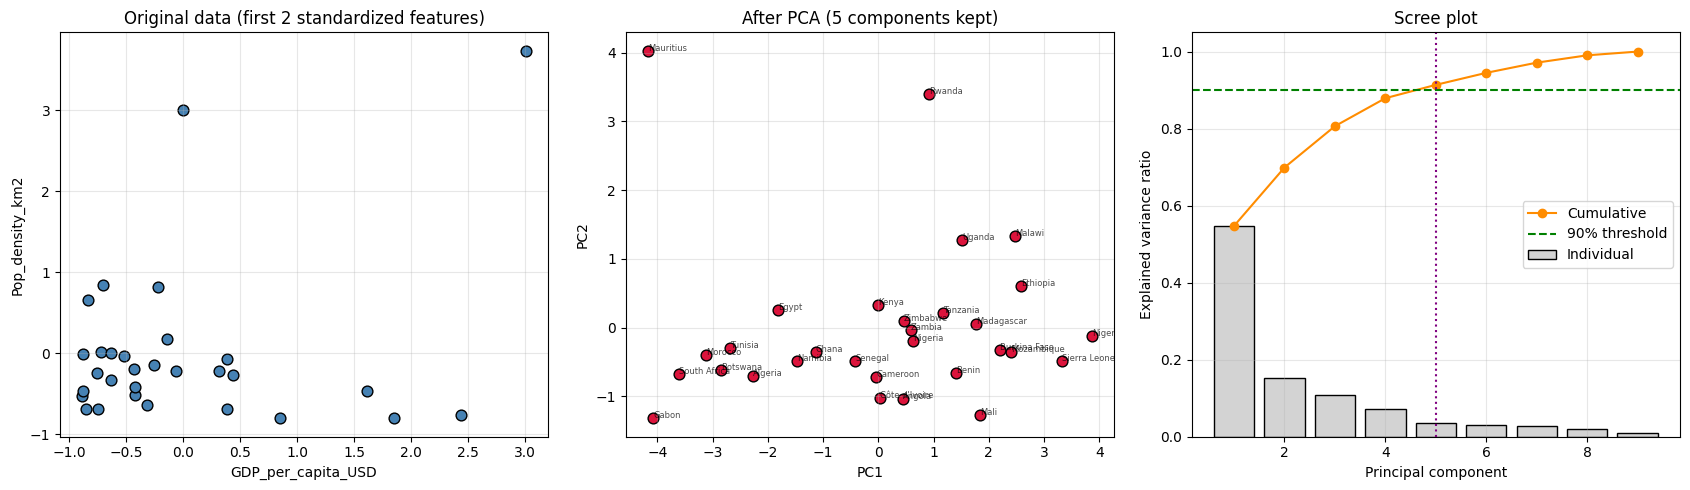

In [9]:
# Step 8: Visualize Before and After PCA
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# (A) Original data: first two standardized features
ax[0].scatter(standardized_data[:, 0], standardized_data[:, 1], c='steelblue', s=60, edgecolor='k')
ax[0].set_xlabel(feature_names[0]); ax[0].set_ylabel(feature_names[1])
ax[0].set_title('Original data (first 2 standardized features)')
ax[0].grid(alpha=0.3)

# (B) Reduced data after PCA: PC1 vs PC2
ax[1].scatter(reduced_data[:, 0], reduced_data[:, 1], c='crimson', s=60, edgecolor='k')
for i, name in enumerate(labels):          # annotate countries
    ax[1].annotate(name, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=6, alpha=0.7)
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
ax[1].set_title(f'After PCA ({num_components} components kept)')
ax[1].grid(alpha=0.3)

# (C) Scree + cumulative variance
comps = np.arange(1, len(explained_variance_ratio) + 1)
ax[2].bar(comps, explained_variance_ratio, color='lightgray', edgecolor='k', label='Individual')
ax[2].plot(comps, cumulative_variance, 'o-', color='darkorange', label='Cumulative')
ax[2].axhline(variance_threshold, ls='--', color='green', label=f'{variance_threshold:.0%} threshold')
ax[2].axvline(num_components, ls=':', color='purple')
ax[2].set_xlabel('Principal component'); ax[2].set_ylabel('Explained variance ratio')
ax[2].set_title('Scree plot'); ax[2].legend(); ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Answers (max 5 lines each):**

**1. Interpretation of the PCA visual (before vs after)**
The original data shows many overlapping patterns because it has 9 features.
After PCA, the data becomes more structured and easier to separate visually.
Points that were scattered in high dimensions now cluster more clearly in reduced space.
This shows that PCA successfully captures the main structure of the data.
It simplifies visualization while preserving meaningful relationships.

**2. Why 5 principal components were selected + tradeoff**
Five components were selected because they retain 91.36% of the total variance.
This means most of the important information is preserved in a smaller space.
The tradeoff is reduced complexity versus a small loss of detail.
Fewer components improve efficiency and reduce redundancy in variables.
However, about 8.64% of variation is lost during compression.

**3. Information lost (economic activity / population pressure context)**
Some detailed variation in GDP, population density, and literacy rates is lost.
Small differences in economic activity between countries become less visible.
Subtle patterns in population pressure and urbanization may be compressed.
Minor variations in electricity access and internet usage are also reduced.
However, major socioeconomic trends across countries are still preserved.

### Task 3: Optimize for performance & handle large datasets

For tall datasets (many rows) the covariance + `eigh` route scales with the number of **features**, not rows, so it stays cheap. For very wide data, an **SVD-based** PCA avoids forming the covariance matrix explicitly and is more numerically stable. Below we (a) wrap PCA in a reusable numpy-only function and (b) benchmark covariance-eigendecomposition vs SVD on a large synthetic matrix — results match to numerical precision.

In [10]:
# Task 3: numpy-only PCA function (reusable) + SVD variant
def pca_cov(X, k):
    Xc = (X - X.mean(0)) / X.std(0)
    C = np.cov(Xc, rowvar=False)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1]
    return Xc @ V[:, idx[:k]]

def pca_svd(X, k):
    Xc = (X - X.mean(0)) / X.std(0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)  # no covariance matrix formed
    return Xc @ Vt[:k].T

# Verify both give the same subspace on our real data (sign-invariant)
a = pca_cov(data, num_components)
b = pca_svd(data, num_components)
print('Cov vs SVD agree (abs):', np.allclose(np.abs(a), np.abs(b), atol=1e-6))
a[:3]

Cov vs SVD agree (abs): True


array([[ 0.62213135, -0.20100286, -1.08238895, -1.30699944, -0.74716511],
       [-1.8183163 ,  0.26306464, -0.10857256,  0.74820278,  0.83828161],
       [-3.60739674, -0.6716177 , -0.20628109, -1.07646921,  0.18479911]])

In [11]:
# Benchmark on a large synthetic dataset: 200,000 rows x 50 features
import time
big = np.random.randn(200_000, 50)

t0 = time.perf_counter(); _ = pca_cov(big, 5); t_cov = time.perf_counter() - t0
t0 = time.perf_counter(); _ = pca_svd(big, 5); t_svd = time.perf_counter() - t0

print(f'Dataset: {big.shape[0]:,} rows x {big.shape[1]} features')
print(f'Covariance + eigh : {t_cov:.3f} s')
print(f'SVD               : {t_svd:.3f} s')
print('-> Covariance route is fastest for tall/skinny data (cost set by #features);')
print('   SVD is preferred when features are very many or higher numerical stability is needed.')

Dataset: 200,000 rows x 50 features
Covariance + eigh : 1.192 s
SVD               : 1.993 s
-> Covariance route is fastest for tall/skinny data (cost set by #features);
   SVD is preferred when features are very many or higher numerical stability is needed.
